In [4]:
import sys
import os
sys.path.append(os.path.abspath("../.."))
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification
from tinyconformal.classifier import BinaryMarginalConformalClassifier
from tinyshift.plot import efficiency_curve, reliability_curve, confusion_matrix
from sklearn.model_selection import cross_val_score
import numpy as np
from pathlib import Path

In [6]:
EXAMPLES_DIR = Path.cwd().parent
if str(EXAMPLES_DIR) not in sys.path:
    sys.path.insert(0, str(EXAMPLES_DIR))
from utils.plot_utils import histogram

In [7]:
weights = [0.2, 0.8]

X, y = make_classification(
    n_samples=100000, 
    n_features=20, 
    n_informative=2,      
    weights=weights, 
    random_state=42,
    n_redundant=2)

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_calib, y_train, y_calib = train_test_split(X_train, y_train, test_size=0.25, random_state=42)

In [9]:
rf = RandomForestClassifier(random_state=42, n_jobs=-1, class_weight="balanced", max_depth=int(np.ceil(np.log2(len(X_train)) - 1)))
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,15
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [10]:
score = cross_val_score(rf, X_train, y_train, cv=5, scoring='accuracy', n_jobs=-1)
beta = round(np.mean(1 - score), 3)

In [11]:
clf = BinaryMarginalConformalClassifier(rf)
clf.unlabeled_fit(X_calib, beta)

,learner,RandomForestC...ndom_state=42)
,alpha,0.05
,n_estimators,100
,criterion,'gini'
,max_depth,15
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0


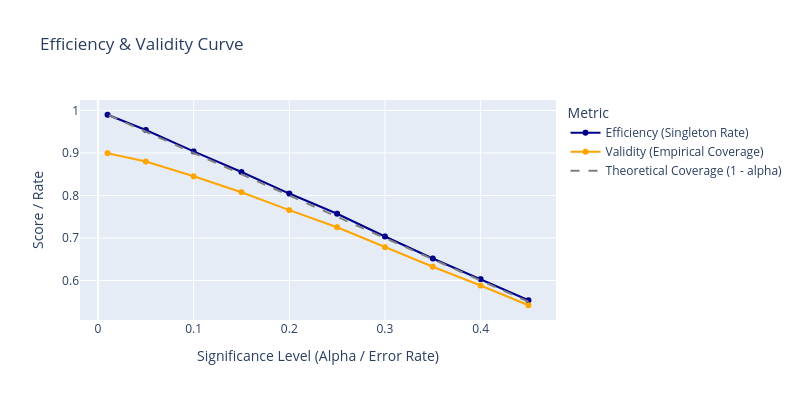

In [12]:
efficiency_curve(clf, X_test, y_test, "png")

In [13]:
clf.evaluate(X_test, y_test, alpha=0.01)

{'total': 20000,
 'alpha': 0.01,
 'beta': np.float64(0.096),
 'coverage_rate': np.float64(0.9),
 'one_c': np.float64(0.99),
 'avg_c': np.float64(0.99),
 'empty': np.float64(0.01),
 'error': np.float64(0.1),
 'log_loss': np.float64(0.255),
 'ece': np.float64(0.023),
 'bm': np.float64(0.733),
 'mcc': np.float64(0.711),
 'f1': np.float64(0.939),
 'fpr': np.float64(0.195)}

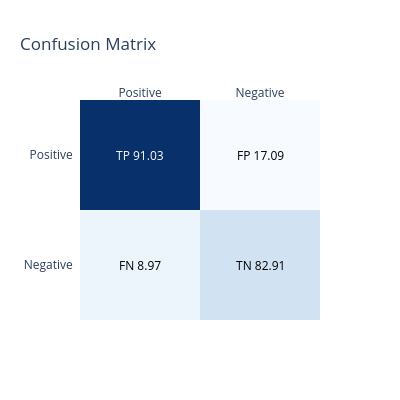

In [14]:
confusion_matrix(clf, X_test, y_test, fig_type="png")

Random Forest

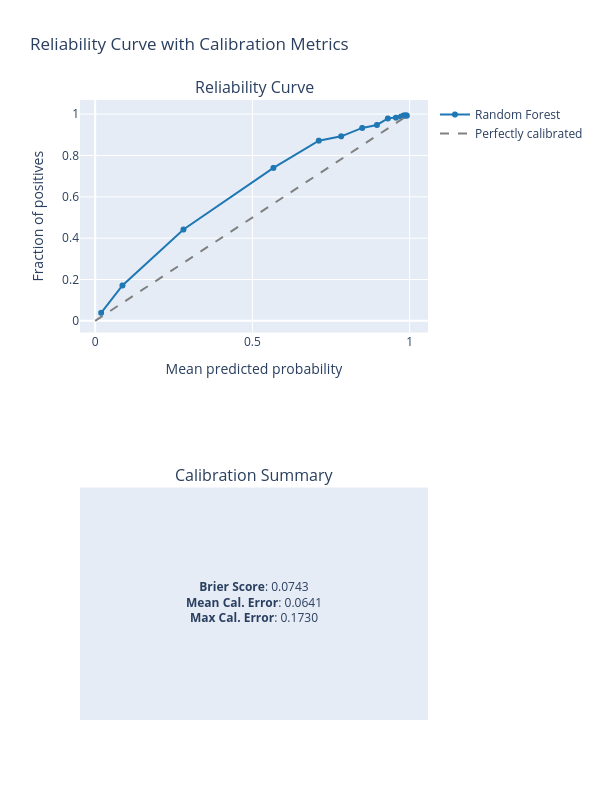

In [15]:
reliability_curve(clf.learner, X_test, y_test, "Random Forest", 15, "png")

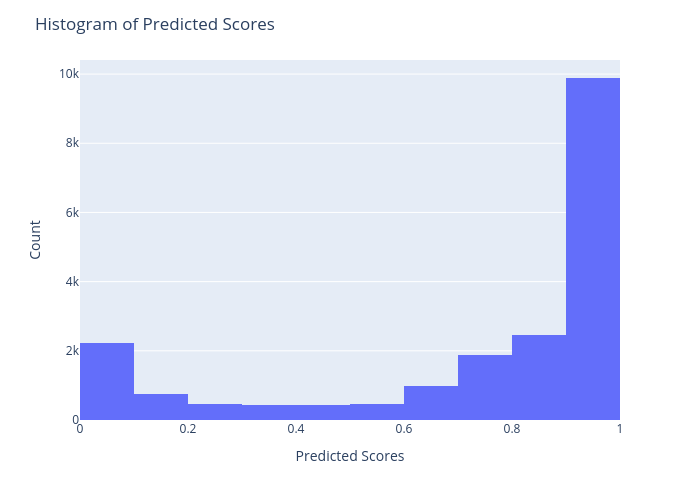

In [16]:
histogram(clf.learner, X_test, 15, "png")

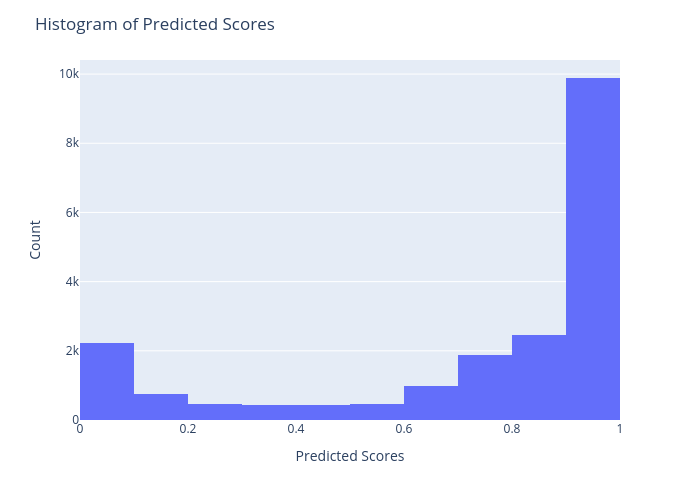

In [17]:
histogram(clf, X_test, 15, "png")

Alpha - 0.05

In [18]:
clf.evaluate(X_test, y_test, alpha=0.05)

{'total': 20000,
 'alpha': 0.05,
 'beta': np.float64(0.096),
 'coverage_rate': np.float64(0.88),
 'one_c': np.float64(0.954),
 'avg_c': np.float64(0.954),
 'empty': np.float64(0.046),
 'error': np.float64(0.12),
 'log_loss': np.float64(0.255),
 'ece': np.float64(0.023),
 'bm': np.float64(0.739),
 'mcc': np.float64(0.696),
 'f1': np.float64(0.932),
 'fpr': np.float64(0.171)}

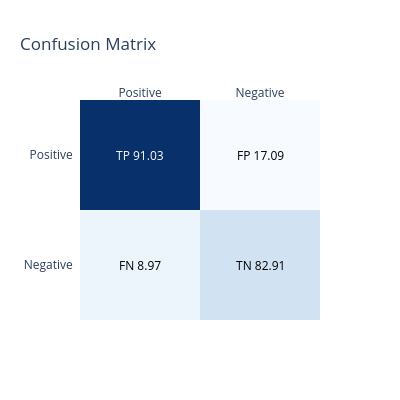

In [19]:
clf.alpha = 0.05
confusion_matrix(clf, X_test, y_test, fig_type="png")

Alpha - 0.10

In [20]:
clf.evaluate(X_test, y_test, alpha=0.10)

{'total': 20000,
 'alpha': 0.1,
 'beta': np.float64(0.096),
 'coverage_rate': np.float64(0.845),
 'one_c': np.float64(0.904),
 'avg_c': np.float64(0.904),
 'empty': np.float64(0.096),
 'error': np.float64(0.155),
 'log_loss': np.float64(0.255),
 'ece': np.float64(0.023),
 'bm': np.float64(0.739),
 'mcc': np.float64(0.667),
 'f1': np.float64(0.917),
 'fpr': np.float64(0.137)}

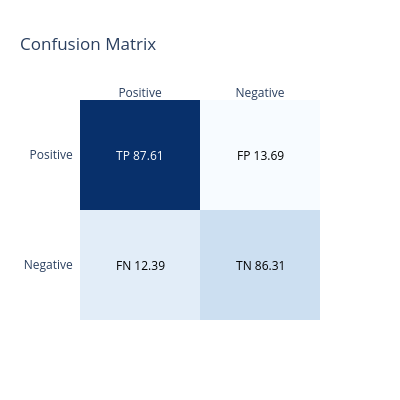

In [21]:
clf.alpha = 0.10
confusion_matrix(clf, X_test, y_test, fig_type="png")